# Linear Discriminant Analysis — one number instead of thirty

## The story

Meera reads biopsy slides in a pathology lab. Every slide comes back from the
imaging machine as **thirty numbers**: mean radius, mean texture, worst
concavity, and twenty-seven more. Her job is one word: **malignant** or
**benign**.

Thirty numbers is too many to look at. So she tried the obvious thing first.

**She plotted one column at a time.** Mean texture for malignant, mean texture
for benign. The two histograms sat almost on top of each other. She tried
another column. Same. A few columns were better than the rest, but none of them
cut the two groups apart on their own.

**Then she tried PCA.** PCA takes thirty columns and hands back one or two.
That is exactly the shape she wanted — and the answer was still a mess. PCA
never looked at the labels. It found the direction where the biopsies are *most
spread out*, and in this data the biggest spread is "big tumours vs small
tumours", not "malignant vs benign". PCA optimised the wrong thing.

Meera does not want the direction with the most spread. She wants the direction
where **the two groups sit furthest apart**. That direction is what Linear
Discriminant Analysis finds.

## What LDA actually does

LDA looks for a single direction — call it **w** — and squashes every point onto
it. One point, thirty numbers, becomes one point, one number:

$$z = wᵀx      (one number per biopsy)$$

Any direction can do that. LDA picks the one that makes the two class centres
land far apart, **while each class stays tight around its own centre**.

Both halves matter, and this is the whole idea:

| | What it means | LDA wants it |
|---|---|---|
| Between-class distance | how far apart the two class centres are after projecting | large |
| Within-class scatter | how spread out each class is around its own centre after projecting | small |

A direction that pushes the centres far apart is useless if it also smears each
class over the whole line. LDA maximises the ratio of the two.

> 📘 **Instructor Curriculum** — Session 21.

## Setup

Four tools, and nothing else:

- `numpy` — for the matrix work, so LDA is not a black box.
- `matplotlib` — every figure below.
- `sklearn.datasets` — the real breast-cancer data Meera works with.
- `LinearDiscriminantAnalysis` — the library version, which we check our own
  arithmetic against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine, make_moons
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)

# one palette for the whole notebook, so the same class is the same colour everywhere
C1, C2 = "#e4572e", "#1f7a8c"      # class 1 / class 2
GREY   = "#8d99ae"

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
print("ready")

ready


## First, four points Meera can check by hand

Thirty columns is impossible to follow with a pencil. Two columns and four
points is not. So before touching the real data, we do the whole method by hand
on a toy set:

- **Class 1**: x₁ = (2, 3), x₂ = (3, 4)
- **Class 2**: x₃ = (6, 7), x₄ = (7, 10)

Every number that comes out of the next few cells is a number you can check on
paper.

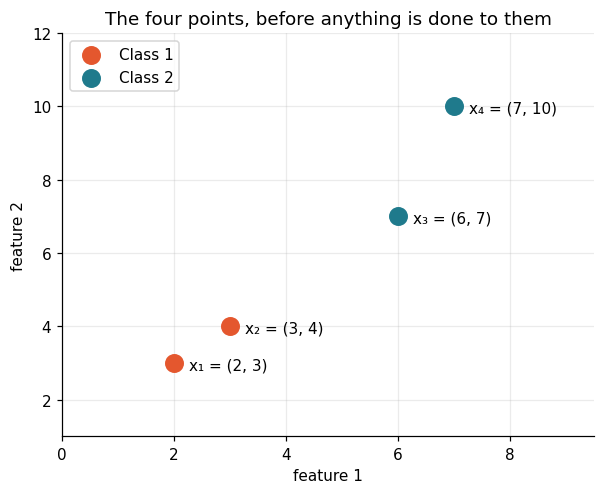

In [2]:
X_toy = np.array([[2., 3.],
                  [3., 4.],
                  [6., 7.],
                  [7., 10.]])
y_toy = np.array([0, 0, 1, 1])          # 0 -> class 1, 1 -> class 2

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.scatter(*X_toy[y_toy == 0].T, s=130, c=C1, label="Class 1", zorder=3)
ax.scatter(*X_toy[y_toy == 1].T, s=130, c=C2, label="Class 2", zorder=3)
for (px, py), name in zip(X_toy, ["x₁", "x₂", "x₃", "x₄"]):
    ax.annotate(f"{name} = ({px:g}, {py:g})", (px, py),
                textcoords="offset points", xytext=(10, -4), fontsize=10)
ax.set(xlabel="feature 1", ylabel="feature 2",
       title="The four points, before anything is done to them",
       xlim=(0, 9.5), ylim=(1, 12))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step I — the centre of each class

Start with the plain average of each class. Nothing clever yet.

$$μ_c = (1/n_c) · Σ x      for the points x in class c$$

In [3]:
mu1 = X_toy[y_toy == 0].mean(axis=0)
mu2 = X_toy[y_toy == 1].mean(axis=0)

print("mu1 (class 1) =", mu1)     # (2+3)/2 , (3+4)/2
print("mu2 (class 2) =", mu2)     # (6+7)/2 , (7+10)/2
print("mean difference (mu2 - mu1) =", mu2 - mu1)

mu1 (class 1) = [2.5 3.5]
mu2 (class 2) = [6.5 8.5]
mean difference (mu2 - mu1) = [4. 5.]


## Step II — how spread out is each class?

Now measure how much each class wobbles around its own centre. For one class:

$$S_c = Σ (x − μ_c)(x − μ_c)ᵀ$$

Read it left to right: take a point, subtract its class centre, and multiply
that little column vector by its own transpose. A 2×1 times a 1×2 gives a 2×2
matrix. Add up one such matrix per point.

That matrix is the **scatter** of the class: how far its points sit from its
centre, and in which direction they lean.

Adding the two class scatters together gives the **within-class scatter**:

$$S_w = S₁ + S₂$$

In [4]:
def scatter_matrix(points, mu):
    '''Sum of (x - mu)(x - mu)^T over the rows of `points`.'''
    S = np.zeros((points.shape[1], points.shape[1]))
    for x in points:
        d = (x - mu).reshape(-1, 1)      # column vector, shape (2, 1)
        S += d @ d.T                     # (2,1) @ (1,2) -> (2,2)
    return S

S1 = scatter_matrix(X_toy[y_toy == 0], mu1)
S2 = scatter_matrix(X_toy[y_toy == 1], mu2)
Sw = S1 + S2

print("S1 =\n", S1)
print("\nS2 =\n", S2)
print("\nSw = S1 + S2 =\n", Sw)

S1 =
 [[0.5 0.5]
 [0.5 0.5]]

S2 =
 [[0.5 1.5]
 [1.5 4.5]]

Sw = S1 + S2 =
 [[1. 2.]
 [2. 5.]]


Those are the same three matrices you get on paper:

$$S₁ = [[0.5, 0.5], [0.5, 0.5]]      S₂ = [[0.5, 1.5], [1.5, 4.5]]      S_w = [[1, 2], [2, 5]]$$

S₂ is the bigger of the two, and it leans hard along feature 2 — class 2's points
are (6, 7) and (7, 10), so they differ by 1 across and 3 up. The scatter matrix
records that lean. LDA is about to use it.

## Why the scatter has to be in the formula

The obvious guess for the best direction is the straight line between the two
centres, μ₂ − μ₁. It is wrong often enough to matter, and here is the picture
that shows why.

Below are two classes that overlap when you project them onto the line joining
their centres — because both classes are stretched in almost that same
direction. Dividing the mean difference by the within-class scatter turns the
direction to something that separates them cleanly.

In [5]:
# Two classes shaped like long thin cigars, both leaning the same way.
# Sigma is built from its own axes: long (variance 16) along [1,1],
# thin (variance 0.25) along [1,-1].
e_long, e_thin = np.array([1, 1]) / np.sqrt(2), np.array([1, -1]) / np.sqrt(2)
cov = 16 * np.outer(e_long, e_long) + 0.25 * np.outer(e_thin, e_thin)

# the centres are 5 apart along the long axis and 2.2 apart along the thin one
m_a = np.array([0.0, 0.0])
m_b = 5.0 * e_long + 2.2 * e_thin

rng = np.random.RandomState(0)
A = rng.multivariate_normal(m_a, cov, 300)
B = rng.multivariate_normal(m_b, cov, 300)
Xd = np.vstack([A, B]);  yd = np.r_[np.zeros(300), np.ones(300)]

mean_dir = m_b - m_a                                # the naive guess
Sw_d     = scatter_matrix(A, A.mean(0)) + scatter_matrix(B, B.mean(0))
lda_dir  = np.linalg.inv(Sw_d) @ mean_dir           # the LDA answer

unit = lambda v: v / np.linalg.norm(v)

def separation(direction):
    '''Gap between the two centres after projecting, measured in class-widths.'''
    a, b = A @ unit(direction), B @ unit(direction)
    return abs(a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

print("mean-difference direction :", unit(mean_dir).round(3),
      " gap =", round(separation(mean_dir), 2), "class-widths")
print("LDA direction             :", unit(lda_dir).round(3),
      " gap =", round(separation(lda_dir), 2), "class-widths")

mean-difference direction : [0.932 0.362]  gap = 1.38 class-widths
LDA direction             : [ 0.732 -0.682]  gap = 4.64 class-widths


/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_25352/4146027685.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


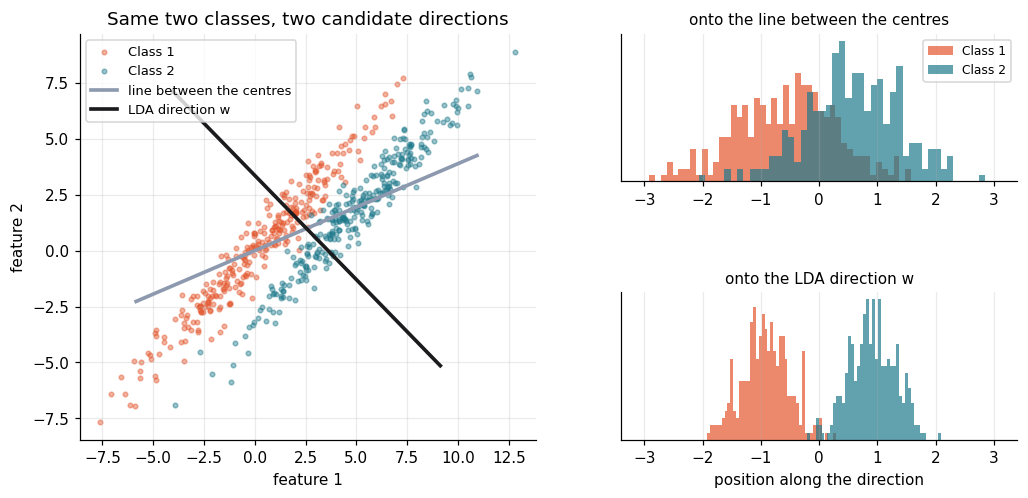

In [6]:
fig = plt.figure(figsize=(11, 4.8))
gs  = fig.add_gridspec(2, 2, width_ratios=[1.15, 1], hspace=.75)
ax  = fig.add_subplot(gs[:, 0])

# left: the cloud, with both candidate directions drawn through it
ax.scatter(*A.T, s=9, c=C1, alpha=.45, label="Class 1")
ax.scatter(*B.T, s=9, c=C2, alpha=.45, label="Class 2")
mid = (m_a + m_b) / 2
for d, col, lab in [(mean_dir, GREY, "line between the centres"),
                    (lda_dir, "#1b1b1e", "LDA direction w")]:
    u = unit(d) * 9
    ax.plot([mid[0] - u[0], mid[0] + u[0]], [mid[1] - u[1], mid[1] + u[1]],
            color=col, lw=2.4, label=lab)
ax.set(title="Same two classes, two candidate directions",
       xlabel="feature 1", ylabel="feature 2")
ax.legend(fontsize=8.5, loc="upper left")

# right: what each direction does once the points are squashed onto it
for row, (d, lab) in enumerate([(mean_dir, "onto the line between the centres"),
                                (lda_dir, "onto the LDA direction w")]):
    axh = fig.add_subplot(gs[row, 1])
    a, b = A @ unit(d), B @ unit(d)
    both = np.r_[a, b]
    a, b = (a - both.mean()) / both.std(), (b - both.mean()) / both.std()
    axh.hist(a, bins=45, color=C1, alpha=.7, label="Class 1")
    axh.hist(b, bins=45, color=C2, alpha=.7, label="Class 2")
    axh.set(title=lab, yticks=[], xlim=(-3.4, 3.4))
    axh.title.set_size(10)
    if row == 0:
        axh.legend(fontsize=8, loc="upper right")
    else:
        axh.set_xlabel("position along the direction")
plt.tight_layout()
plt.show()

The top row is the naive direction: the two classes bleed into each other. The
bottom row is LDA: two clean humps. Same points, same labels — only the
direction changed.

That is what dividing by S_w buys you.

## Step III — the direction

With the mean difference and the within-class scatter in hand, the direction is
one line of arithmetic:

$$w = S_w⁻¹ (μ₂ − μ₁)$$

Back to the four toy points. S_w = [[1, 2], [2, 5]], so its determinant is
1·5 − 2·2 = 1, and the inverse is [[5, −2], [−2, 1]]. The mean difference is
(4, 5).

In [7]:
Sw_inv = np.linalg.inv(Sw)
w = Sw_inv @ (mu2 - mu1)

print("Sw inverse =\n", Sw_inv)
print("\nw = Sw_inv @ (mu2 - mu1) =", w)        # [5*4 + (-2)*5 , -2*4 + 1*5]

Sw inverse =
 [[ 5. -2.]
 [-2.  1.]]

w = Sw_inv @ (mu2 - mu1) = [10. -3.]


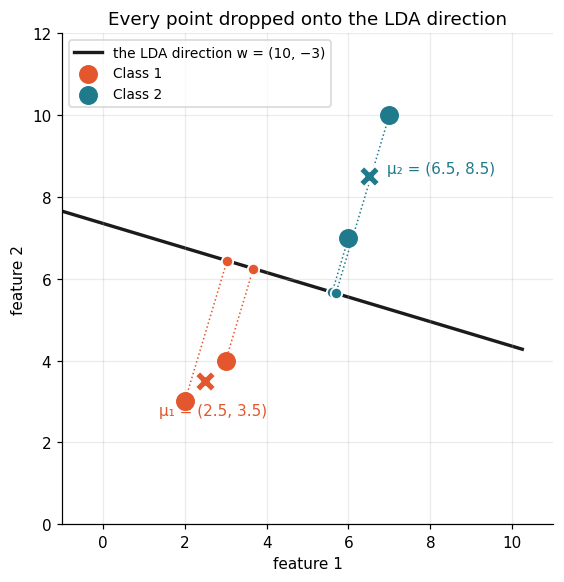

In [8]:
u = w / np.linalg.norm(w)          # unit vector along the LDA direction
c = X_toy.mean(axis=0)             # a point to hang the line on

fig, ax = plt.subplots(figsize=(6.4, 5.4))

# the LDA axis itself
line = np.array([c - u * 6, c + u * 6])
ax.plot(*line.T, color="#1b1b1e", lw=2.2, zorder=1, label="the LDA direction w = (10, −3)")

# drop every point onto that axis, at a right angle
for (px, py), cls in zip(X_toy, y_toy):
    foot = c + ((np.array([px, py]) - c) @ u) * u
    col = C1 if cls == 0 else C2
    ax.plot([px, foot[0]], [py, foot[1]], color=col, lw=1, ls=":", zorder=2)
    ax.scatter(*foot, s=55, c=col, edgecolor="w", lw=1.2, zorder=4)

ax.scatter(*X_toy[y_toy == 0].T, s=130, c=C1, label="Class 1", zorder=3)
ax.scatter(*X_toy[y_toy == 1].T, s=130, c=C2, label="Class 2", zorder=3)
ax.scatter(*mu1, s=200, marker="X", c=C1, edgecolor="w", lw=1.6, zorder=5)
ax.scatter(*mu2, s=200, marker="X", c=C2, edgecolor="w", lw=1.6, zorder=5)
ax.annotate("μ₁ = (2.5, 3.5)", mu1, textcoords="offset points", xytext=(-30, -22),
            color=C1, zorder=6)
ax.annotate("μ₂ = (6.5, 8.5)", mu2, textcoords="offset points", xytext=(12, 2),
            color=C2, zorder=6)

ax.set(xlabel="feature 1", ylabel="feature 2", xlim=(-1, 11), ylim=(0, 12),
       title="Every point dropped onto the LDA direction")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

w comes out as **(10, −3)**.

Notice it does not point from μ₁ to μ₂ — that would be (4, 5), up and to the
right. It points down and to the right. S_w⁻¹ turned it, because class 2 is
stretched upwards and LDA refuses to trust a direction that runs along a class's
own spread.

## Step IV — project the points onto the line

Now use w on each point. This is the whole of "reduce the dimensions": a dot
product.

$$z = wᵀx = 10·(feature 1) − 3·(feature 2)$$

For x₁ = (2, 3) that is 10·2 − 3·3 = 20 − 9 = **11**.

In [9]:
z = X_toy @ w

for (px, py), zi, cls in zip(X_toy, z, y_toy):
    print(f"({px:g}, {py:g})  ->  10*{px:g} - 3*{py:g} = {zi:6.1f}   class {cls + 1}")

print("\nclass 1 centre on the line:", (mu1 @ w))
print("class 2 centre on the line:", (mu2 @ w))

(2, 3)  ->  10*2 - 3*3 =   11.0   class 1
(3, 4)  ->  10*3 - 3*4 =   18.0   class 1
(6, 7)  ->  10*6 - 3*7 =   39.0   class 2
(7, 10)  ->  10*7 - 3*10 =   40.0   class 2

class 1 centre on the line: 14.5
class 2 centre on the line: 39.5


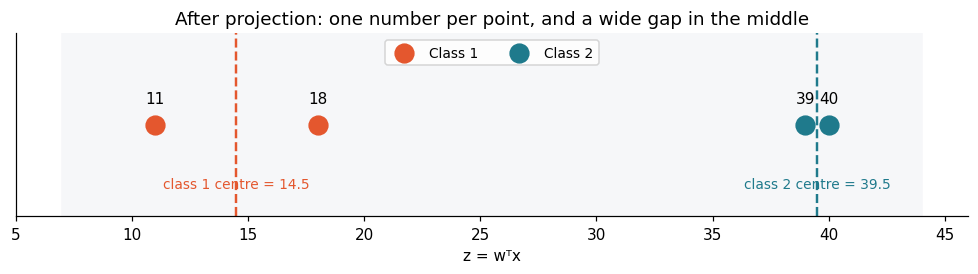

In [10]:
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.scatter(z[y_toy == 0], [0, 0], s=150, c=C1, zorder=3, label="Class 1")
ax.scatter(z[y_toy == 1], [0, 0], s=150, c=C2, zorder=3, label="Class 2")
for zi in z:
    ax.annotate(f"{zi:g}", (zi, 0), textcoords="offset points", xytext=(0, 14),
                ha="center", fontsize=10)

z1c, z2c = mu1 @ w, mu2 @ w
for zc, col, lab in [(z1c, C1, f"class 1 centre = {z1c:g}"), (z2c, C2, f"class 2 centre = {z2c:g}")]:
    ax.axvline(zc, color=col, ls="--", lw=1.6)
    ax.annotate(lab, (zc, -.55), ha="center", fontsize=9, color=col)

ax.axvspan(z.min() - 4, z.max() + 4, color="#f6f7f9", zorder=0)
ax.set(title="After projection: one number per point, and a wide gap in the middle",
       xlabel="z = wᵀx", yticks=[], ylim=(-.8, .8), xlim=(5, 46))
ax.grid(False)
ax.legend(loc="upper center", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

Two dimensions became one, and the two classes did not smear together — they
ended up at **14.5** and **39.5**, with nothing in between. Anything below about
25 is class 1, anything above is class 2. That single threshold is the classifier.

## Does the library agree?

The hand arithmetic is only worth trusting if scikit-learn lands on the same
line. It scales `w` differently — the length of the vector is arbitrary, only its
direction carries meaning — so compare the directions, not the raw numbers.

In [11]:
lda_toy = LinearDiscriminantAnalysis(n_components=1).fit(X_toy, y_toy)

ours    = w / np.linalg.norm(w)
theirs  = lda_toy.scalings_[:, 0] / np.linalg.norm(lda_toy.scalings_[:, 0])

print("our direction     :", ours.round(4))
print("sklearn direction :", theirs.round(4))
print("\nsame line?", np.allclose(np.abs(ours @ theirs), 1.0))

our direction     : [ 0.9578 -0.2873]
sklearn direction : [ 0.9578 -0.2873]

same line? True


## Why not PCA?

This is the failure Meera hit at the start, made visible. Both PCA and LDA take
many columns and hand back fewer. The difference is what they optimise:

| | Uses the labels? | Keeps the direction of… |
|---|---|---|
| PCA | no | the **most spread** in the data |
| LDA | yes | the **best separation** between the classes |

When the biggest spread happens to run along the split, PCA looks fine. When it
does not, PCA throws the answer away.

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_25352/1331884518.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


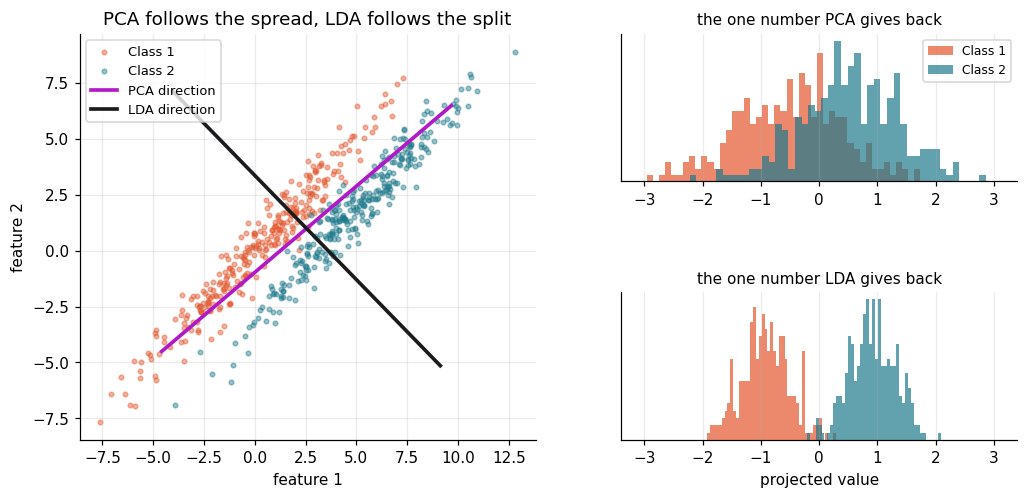

PCA direction: gap = 1.2 class-widths
LDA direction: gap = 4.64 class-widths


In [12]:
pca_dir = PCA(n_components=1).fit(Xd).components_[0]

fig = plt.figure(figsize=(11, 4.8))
gs  = fig.add_gridspec(2, 2, width_ratios=[1.15, 1], hspace=.75)
ax  = fig.add_subplot(gs[:, 0])

ax.scatter(*A.T, s=9, c=C1, alpha=.45, label="Class 1")
ax.scatter(*B.T, s=9, c=C2, alpha=.45, label="Class 2")
for d, col, lab in [(pca_dir, "#b118c8", "PCA direction"),
                    (lda_dir, "#1b1b1e", "LDA direction")]:
    u = unit(d) * 9
    ax.plot([mid[0] - u[0], mid[0] + u[0]], [mid[1] - u[1], mid[1] + u[1]],
            color=col, lw=2.4, label=lab)
ax.set(title="PCA follows the spread, LDA follows the split",
       xlabel="feature 1", ylabel="feature 2")
ax.legend(fontsize=8.5, loc="upper left")

for row, (d, lab) in enumerate([(pca_dir, "the one number PCA gives back"),
                                (lda_dir, "the one number LDA gives back")]):
    axh = fig.add_subplot(gs[row, 1])
    a, b = A @ unit(d), B @ unit(d)
    both = np.r_[a, b]
    a, b = (a - both.mean()) / both.std(), (b - both.mean()) / both.std()
    axh.hist(a, bins=45, color=C1, alpha=.7, label="Class 1")
    axh.hist(b, bins=45, color=C2, alpha=.7, label="Class 2")
    axh.set(title=lab, yticks=[], xlim=(-3.4, 3.4))
    axh.title.set_size(10)
    if row == 0:
        axh.legend(fontsize=8, loc="upper right")
    else:
        axh.set_xlabel("projected value")
plt.tight_layout()
plt.show()

print("PCA direction: gap =", round(separation(pca_dir), 2), "class-widths")
print("LDA direction: gap =", round(separation(lda_dir), 2), "class-widths")

Same data, same one dimension kept. PCA hands back a single blurred pile. LDA
hands back two humps you can cut with one threshold.

PCA is not broken — it is answering a different question. It is unsupervised, so
it has no idea the labels exist.

## Now the real thing: thirty columns of biopsy data

This is Meera's actual problem. 569 biopsies, 30 measurements each, and one
label: malignant or benign.

First, the failure that started the story — a single raw column.

X shape: (569, 30)  -> 569 biopsies, 30 measurements each
classes: {np.str_('malignant'): 212, np.str_('benign'): 357}


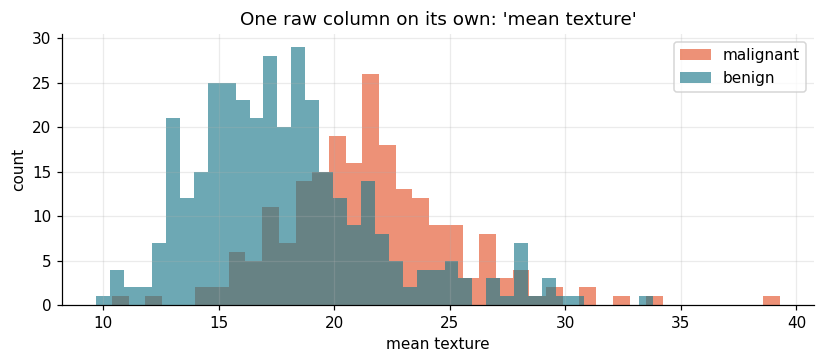

In [13]:
data = load_breast_cancer()
X, y = data.data, data.target          # y: 0 = malignant, 1 = benign

print("X shape:", X.shape, " -> 569 biopsies, 30 measurements each")
print("classes:", {n: int(c) for n, c in zip(data.target_names, np.bincount(y))})

col = list(data.feature_names).index("mean texture")
fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.hist(X[y == 0, col], bins=40, color=C1, alpha=.65, label="malignant")
ax.hist(X[y == 1, col], bins=40, color=C2, alpha=.65, label="benign")
ax.set(title="One raw column on its own: 'mean texture'",
       xlabel="mean texture", ylabel="count")
ax.legend()
plt.tight_layout()
plt.show()

The two histograms sit on top of each other. No threshold on this column
separates the two groups — pick any cut and a large slice of both classes lands
on the wrong side.

Now hand all thirty columns to LDA and ask for **one** number back.

In [14]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)          # (569, 30) -> (569, 1)

malignant_centre = X_lda[y == 0].mean()
benign_centre    = X_lda[y == 1].mean()

print("X_lda shape:", X_lda.shape)
print("malignant centre:", round(malignant_centre, 3))
print("benign centre   :", round(benign_centre, 3))

X_lda shape: (569, 1)
malignant centre: -2.4
benign centre   : 1.425


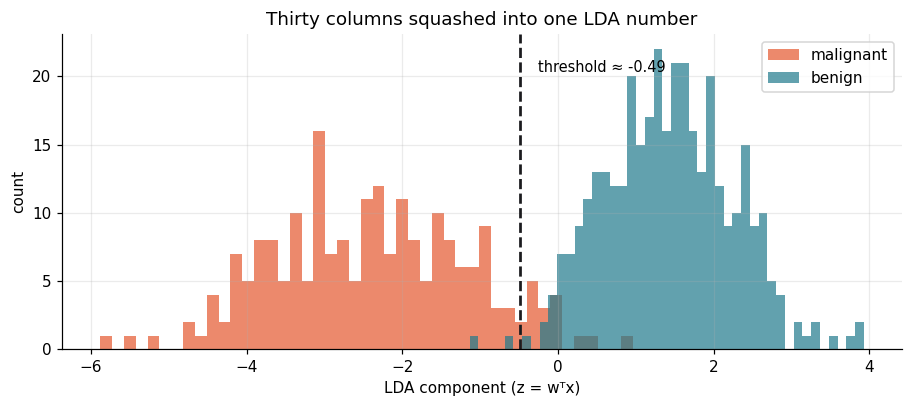

In [15]:
threshold = (malignant_centre + benign_centre) / 2

fig, ax = plt.subplots(figsize=(8.4, 3.8))
ax.hist(X_lda[y == 0], bins=45, color=C1, alpha=.7, label="malignant")
ax.hist(X_lda[y == 1], bins=45, color=C2, alpha=.7, label="benign")
ax.axvline(threshold, color="#1b1b1e", ls="--", lw=1.8)
ax.annotate(f"threshold ≈ {threshold:.2f}", (threshold, ax.get_ylim()[1] * .88),
            xytext=(12, 0), textcoords="offset points", fontsize=9.5)
ax.set(title="Thirty columns squashed into one LDA number",
       xlabel="LDA component (z = wᵀx)", ylabel="count")
ax.legend()
plt.tight_layout()
plt.show()

That is the payoff. The same 569 biopsies that overlapped on every raw column
now sit in two piles with a gap between them, on a single axis. The overlap that
remains — the handful of points either side of the dashed line — is the genuinely
hard cases, not an artefact of looking at the wrong column.

## LDA is also a classifier

Everything so far treated LDA as a way to reduce dimensions. But once you have
the direction and the two centres, classifying is just "which centre is this
point closer to". `sklearn` gives you `.predict()` for free.

One rule matters here: **split first, fit second.** LDA learns the class means
and the scatter from the data. Fitting it on everything and then scoring on the
same rows leaks the test set into the model and reports a number you cannot
trust in production.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

clf = LinearDiscriminantAnalysis().fit(X_train, y_train)   # fit on train only
pred = clf.predict(X_test)

print("test accuracy:", round(accuracy_score(y_test, pred), 4))
print("\nconfusion matrix (rows = truth, cols = predicted)")
print("                 malignant  benign")
cm = confusion_matrix(y_test, pred)
for name, row in zip(["malignant", "benign   "], cm):
    print(f"      {name}   {row[0]:8d}{row[1]:8d}")

test accuracy: 0.951

confusion matrix (rows = truth, cols = predicted)
                 malignant  benign
      malignant         47       6
      benign             1      89


About 95% on held-out biopsies, from a model that is one vector of thirty
numbers and a threshold.

## How many directions can LDA give you?

This is the one hard limit to remember. With **C** classes, LDA can produce at
most **C − 1** directions.

Two classes give one direction — that is why every projection above was a single
number, and why `n_components=1` was the only choice for the breast-cancer data.
Three classes give two, which is enough for a scatter plot.

wine: (178, 13) with 3 classes -> at most 2 LDA directions


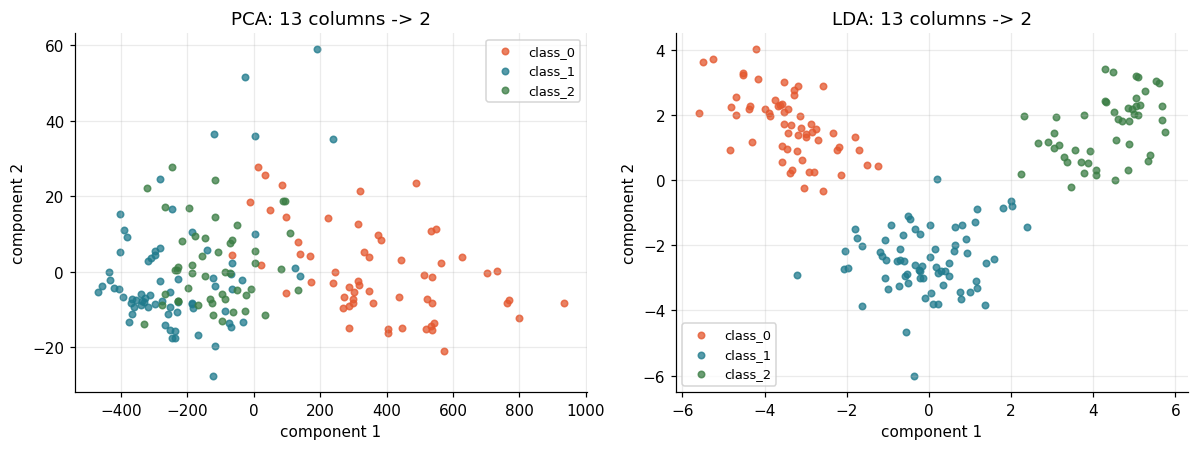

In [17]:
wine = load_wine()
Xw, yw = wine.data, wine.target
print("wine:", Xw.shape, "with", len(np.unique(yw)), "classes -> at most 2 LDA directions")

Xw_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(Xw, yw)
Xw_pca = PCA(n_components=2).fit_transform(Xw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, Z, title in [(axes[0], Xw_pca, "PCA: 13 columns -> 2"),
                     (axes[1], Xw_lda, "LDA: 13 columns -> 2")]:
    for k, col in zip(range(3), [C1, C2, "#3a7d44"]):
        ax.scatter(*Z[yw == k].T, s=18, c=col, alpha=.75, label=wine.target_names[k])
    ax.set(title=title, xlabel="component 1", ylabel="component 2")
    ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

Same thirteen wine columns, same two dimensions kept. PCA's three varieties
touch; LDA's sit in three separate islands, because LDA was told the labels and
went looking for the split.

## Where LDA breaks

LDA draws **one straight line**. It assumes each class is a roughly Gaussian
blob and that all classes have the **same** spread. When the real boundary
curves, no straight line will do, and LDA fails in a very obvious way.

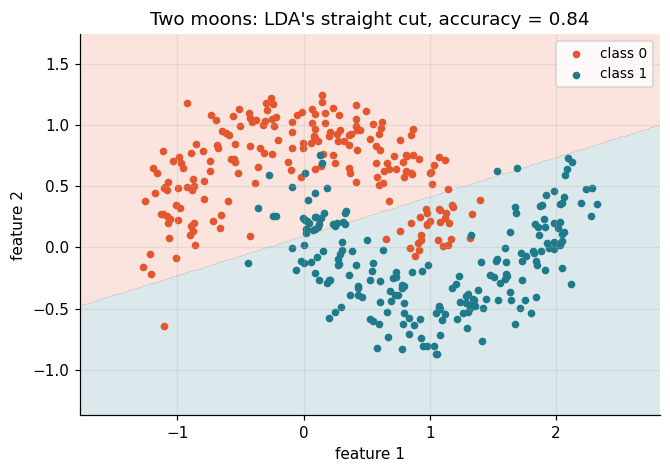

In [18]:
Xm, ym = make_moons(n_samples=400, noise=.18, random_state=42)
moon_clf = LinearDiscriminantAnalysis().fit(Xm, ym)

xx, yy = np.meshgrid(np.linspace(Xm[:, 0].min() - .5, Xm[:, 0].max() + .5, 300),
                     np.linspace(Xm[:, 1].min() - .5, Xm[:, 1].max() + .5, 300))
zz = moon_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.contourf(xx, yy, zz, alpha=.16, colors=[C1, C2], levels=[-.5, .5, 1.5])
ax.scatter(*Xm[ym == 0].T, s=16, c=C1, label="class 0")
ax.scatter(*Xm[ym == 1].T, s=16, c=C2, label="class 1")
ax.set(title=f"Two moons: LDA's straight cut, accuracy = {moon_clf.score(Xm, ym):.2f}",
       xlabel="feature 1", ylabel="feature 2")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

84% on data where a curved boundary gets close to 100%. The straight cut
slices through both moons because a straight cut is all LDA has.

This is not a bug to fix. It is the trade you accept: LDA is fast, needs almost
no tuning, and gives a direction you can read and explain — as long as the split
really is roughly linear.

## Where this shows up in a real system

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor
> curriculum.*

The trained model here is genuinely small: one vector of 30 floats, plus a
threshold. Scoring a biopsy is `sum(w[i] * x[i])` — a dot product, microseconds,
no framework needed at request time.

That has a few practical consequences worth knowing from a services background:

- **Serving is trivial.** The whole model fits in a config row. There is no
  reason to stand up a model server for it; the scoring code is a few lines in
  whatever service already holds the features.
- **It is a feature step, not only a model.** LDA's usual production job is to
  sit inside a `Pipeline` and hand its one or two columns to a heavier model
  downstream. That keeps the fitting inside cross-validation, where it belongs.
- **The weights are readable.** Thirty coefficients you can sort and inspect
  make a far easier conversation with a domain expert than a tree ensemble.
- **It drifts loudly.** The model is class means and scatter. If the incoming
  population shifts, the projected values slide off the threshold, which is one
  cheap number to monitor.

## Common mistakes

1. **Reaching for PCA when the labels exist.** PCA optimises spread, not
   separation. If you have labels and you want separation, LDA is the tool.
2. **Fitting LDA before the train/test split.** The class means and the scatter
   are learned from data. Fit them on the training rows only, inside a
   `Pipeline`.
3. **Asking for more components than C − 1.** Two classes give exactly one
   direction, no matter how many columns went in.
4. **Using it when one class is far more spread out than the other.** LDA pools
   the scatter into a single S_w. When that assumption is badly wrong, use
   `QuadraticDiscriminantAnalysis`, which gives each class its own.

## Key takeaway

**If you remember only one thing:** LDA finds the single direction where the
class centres are far apart *and* each class stays tight, then squashes every
point onto it — `w = S_w⁻¹ (μ₂ − μ₁)`, and `z = wᵀx`.

PCA asks "where is the data most spread out?" LDA asks "where are the classes
most separated?" When you have labels, the second question is usually the one
you meant.